In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
usda = pd.read_csv('../data/usda_expenditures.csv')
usda

,Year,Food at home expenditures million nominal U.S. dollars by households,Food at home expenditures million nominal U.S. dollars by government,Food at home expenditures million nominal U.S. dollars by home production,Food at home expenditures million constant 1988 U.S. dollars by households,Food at home expenditures million constant 1988 U.S. dollars by government,Food at home expenditures million constant 1988 U.S. dollars by home production,Food away from home expenditures million nominal U.S. dollars by households,Food away from home expenditures million nominal U.S. dollars by government,Food away from home expenditures million nominal U.S. dollars by home production,Food away from home expenditures million constant 1988 U.S. dollars by households,Food away from home expenditures million constant 1988 U.S. dollars by government,Food away from home expenditures million constant 1988 U.S. dollars by home production
0,1997,"351,807.63","23,677.15",842.93,"259,460.91","17,462.09",621.67,"265,068.59","16,615.44","54,711.66","205,639.20","12,890.19","42,445.10"
1,1998,"362,463.47","21,095.55",834.88,"262,341.63","15,268.41",604.26,"278,005.19","17,068.33","58,829.70","210,186.42","12,904.55","44,478.32"
2,1999,"384,929.53","20,066.85",812.49,"273,342.16","14,249.66",576.96,"292,034.97","17,662.16","62,424.47","215,444.33","13,029.99","46,052.70"
3,2000,"403,700.19","19,271.68",798.02,"280,354.06","13,383.43",554.19,"313,061.13","18,349.07","67,257.52","225,626.31","13,224.36","48,473.18"
4,2001,"422,530.75","20,155.39",786.39,"284,123.91","13,553.16",528.80,"326,063.38","19,058.11","68,519.59","228,375.63","13,348.35","47,991.30"
5,2002,"427,950.38","23,112.10",799.85,"284,162.94","15,346.64",531.11,"333,840.16","19,854.92","78,676.32","228,052.34","13,563.26","53,745.24"
6,2003,"443,745.44","26,462.25",810.46,"288,409.81","17,198.99",526.76,"354,630.19","20,550.26","80,801.38","237,199.09","13,745.31","54,045.07"
7,2004,"465,712.06","30,025.30",901.64,"291,632.81","18,802.10",564.61,"381,658.00","21,817.28","84,656.77","247,925.05","14,172.51","54,993.04"
8,2005,"490,800.75","34,036.84","1,223.36","301,514.03","20,909.88",751.55,"406,525.94","23,007.29","88,011.28","256,023.06","14,489.60","55,428.00"
9,2006,"514,023.72","35,643.70","1,394.85","310,384.06","21,522.81",842.25,"434,221.66","23,601.49","92,298.11","265,236.72","14,416.56","56,378.69"


In [3]:
usda_filtered = usda[['Year', 
                  'Food at home expenditures million nominal U.S. dollars by households',
                  'Food away from home expenditures million nominal U.S. dollars by households']]
usda_filtered

,Year,Food at home expenditures million nominal U.S. dollars by households,Food away from home expenditures million nominal U.S. dollars by households
0,1997,"351,807.63","265,068.59"
1,1998,"362,463.47","278,005.19"
2,1999,"384,929.53","292,034.97"
3,2000,"403,700.19","313,061.13"
4,2001,"422,530.75","326,063.38"
5,2002,"427,950.38","333,840.16"
6,2003,"443,745.44","354,630.19"
7,2004,"465,712.06","381,658.00"
8,2005,"490,800.75","406,525.94"
9,2006,"514,023.72","434,221.66"


In [4]:
usda_rename = usda_filtered.rename(columns={
    'Food at home expenditures million nominal U.S. dollars by households': 'Food At Home',
    'Food away from home expenditures million nominal U.S. dollars by households': 'Food Away From Home'
})
usda_rename

,Year,Food At Home,Food Away From Home
0,1997,"351,807.63","265,068.59"
1,1998,"362,463.47","278,005.19"
2,1999,"384,929.53","292,034.97"
3,2000,"403,700.19","313,061.13"
4,2001,"422,530.75","326,063.38"
5,2002,"427,950.38","333,840.16"
6,2003,"443,745.44","354,630.19"
7,2004,"465,712.06","381,658.00"
8,2005,"490,800.75","406,525.94"
9,2006,"514,023.72","434,221.66"


In [5]:
households = pd.read_csv('../data/census_households.csv')
households

,Year,Total Households
0,2019,"122,802,852"
1,2020,"122,354,219"
2,2021,"127,544,730"
3,2022,"129,870,928"
4,2023,"131,332,360"


In [6]:
merge_year = usda_rename.merge(households, on='Year')
merge_year.head(1)

,Year,Food At Home,Food Away From Home,Total Households
0,2019,"761,813.06","845,048.00","122,802,852"


In [7]:
merge_year['Total Households'] = (
    merge_year['Total Households']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(int)
)
merge_year.head(1)

,Year,Food At Home,Food Away From Home,Total Households
0,2019,"761,813.06","845,048.00",122802852


In [8]:
merge_year['Food At Home'] = (
    merge_year['Food At Home']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)

merge_year['Food Away From Home'] = (
    merge_year['Food Away From Home']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)
merge_year.head(1)

,Year,Food At Home,Food Away From Home,Total Households
0,2019,761813.06,845048.0,122802852


In [9]:
merge_year['Per Household - Food At Home ($)'] = (merge_year['Food At Home'] * 1_000_000) / merge_year['Total Households']
merge_year['Per Household - Food Away From Home ($)'] = (merge_year['Food Away From Home'] * 1_000_000) / merge_year['Total Households']
merge_year

,Year,Food At Home,Food Away From Home,Total Households,Per Household - Food At Home ($),Per Household - Food Away From Home ($)
0,2019,761813.06,845048.00,122802852,6203.545338,6881.338554
1,2020,805480.88,760042.19,122354219,6583.188439,6211.818409
2,2021,839084.56,913619.94,127544730,6578.747393,7163.133592
3,2022,921681.31,1052251.13,129870928,7096.902472,8102.283908
4,2023,951355.00,1199372.50,131332360,7243.873483,9132.345600


In [10]:
merge_year['Per Household - Food At Home ($)'] = (
    merge_year['Food At Home'] * 1_000_000 / merge_year['Total Households']
)

merge_year['Per Household - Food Away From Home ($)'] = (
    merge_year['Food Away From Home'] * 1_000_000 / merge_year['Total Households']
)
merge_year.head(1)

,Year,Food At Home,Food Away From Home,Total Households,Per Household - Food At Home ($),Per Household - Food Away From Home ($)
0,2019,761813.06,845048.0,122802852,6203.545338,6881.338554


In [11]:
merge_year['Per Household - Food At Home ($)'] = merge_year['Per Household - Food At Home ($)'].round(2)
merge_year['Per Household - Food Away From Home ($)'] = merge_year['Per Household - Food Away From Home ($)'].round(2)
merge_year.head(1)

,Year,Food At Home,Food Away From Home,Total Households,Per Household - Food At Home ($),Per Household - Food Away From Home ($)
0,2019,761813.06,845048.0,122802852,6203.55,6881.34


In [12]:
merge_year.iloc[:, 1:] = merge_year.iloc[:, 1:].applymap(lambda x: f"{x:,.2f}" if isinstance(x, (int, float)) else x)
merge_year.head()

C:\Users\user\AppData\Local\Temp\ipykernel_17096\3491066305.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  merge_year.iloc[:, 1:] = merge_year.iloc[:, 1:].applymap(lambda x: f"{x:,.2f}" if isinstance(x, (int, float)) else x)
C:\Users\user\AppData\Local\Temp\ipykernel_17096\3491066305.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0    761,813.06
1    805,480.88
2    839,084.56
3    921,681.31
4    951,355.00
Name: Food At Home, dtype: object' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  merge_year.iloc[:, 1:] = merge_year.iloc[:, 1:].applymap(lambda x: f"{x:,.2f}" if isinstance(x, (int, float)) else x)
C:\Users\user\AppData\Local\Temp\ipykernel_17096\3491066305.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0      845,048.00
1      760,042.19
2   

,Year,Food At Home,Food Away From Home,Total Households,Per Household - Food At Home ($),Per Household - Food Away From Home ($)
0,2019,"761,813.06","845,048.00","122,802,852.00","6,203.55","6,881.34"
1,2020,"805,480.88","760,042.19","122,354,219.00","6,583.19","6,211.82"
2,2021,"839,084.56","913,619.94","127,544,730.00","6,578.75","7,163.13"
3,2022,"921,681.31","1,052,251.13","129,870,928.00","7,096.90","8,102.28"
4,2023,"951,355.00","1,199,372.50","131,332,360.00","7,243.87","9,132.35"


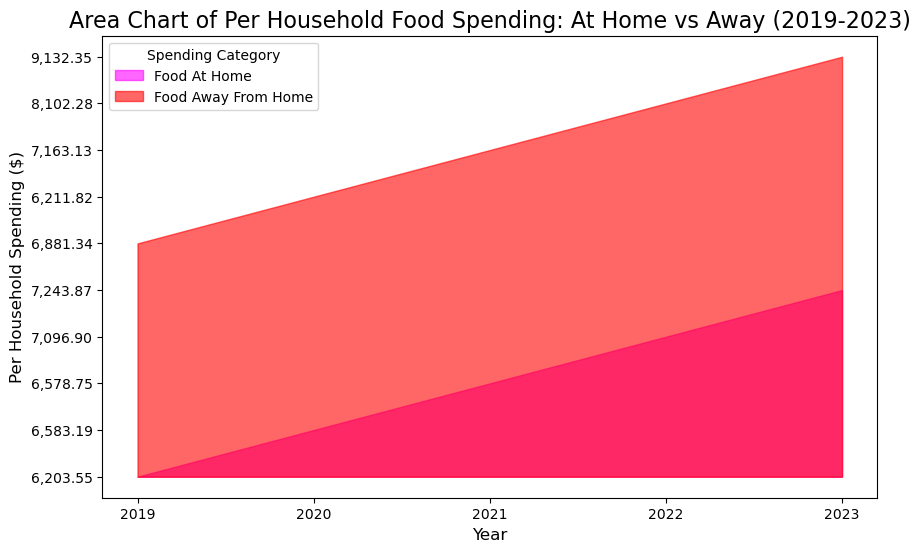

In [61]:
plt.figure(figsize=(10, 6))
plt.fill_between(merge_year['Year'], merge_year['Per Household - Food At Home ($)'], color='magenta', alpha=0.6, label='Food At Home')
plt.fill_between(merge_year['Year'], merge_year['Per Household - Food Away From Home ($)'], color='red', alpha=0.6, label='Food Away From Home')
plt.title('Area Chart of Per Household Food Spending: At Home vs Away (2019-2023)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Per Household Spending ($)', fontsize=12)
plt.legend(title="Spending Category")
plt.xticks(ticks=merge_year['Year'], labels=[int(year) for year in merge_year['Year']])
plt.show()